# Inferencia Taxo-Net
Este notebook toma el modelo entrenado y guardado en `taxonet_best.pth.zip` para probar predicciones taxonómicas en imágenes aleatorias del dataset.

In [5]:
import os
import json
import torch
import random
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms


import numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader



# Configuración
ROOT_DIR = "plantnet_300K"
MODEL_PATH = "taxonet_best.pth"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device detectado: {DEVICE}")

Device detectado: cpu


In [6]:
class PlantNet300K_Hierarchical(Dataset):
    """
    Cargador que acopla cada imagen con su triplete taxonómico:
    (Familia, Género, Especie)
    """
    
    def __init__(self, root_dir: str, split_type: str = 'train', transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        # Cargar metadatos
        metadata_path = os.path.join(root_dir, 'plantnet300K_metadata.json')
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)

        # Cargar nombres de especies
        names_path = os.path.join(root_dir, 'plantnet300K_species_names.json')
        with open(names_path, 'r', encoding='utf-8') as nf:
            species_names = json.load(nf)

        # Mapeo de species_id a índice contiguo
        sorted_sids = sorted(int(k) for k in species_names.keys())
        sid_to_idx = {sid: idx for idx, sid in enumerate(sorted_sids)}

        # Construir mapeos taxonómicos
        genus_names_sorted = sorted({n.split('_')[0] for n in species_names.values()})
        genus_name_to_id = {g: i for i, g in enumerate(genus_names_sorted)}
        GENERA_PER_FAMILY = 5

        def _get_ids(species_id_str):
            name = species_names.get(str(species_id_str), '_unknown')
            genus = name.split('_')[0]
            gid = genus_name_to_id.get(genus, 0)
            fid = gid // GENERA_PER_FAMILY
            return fid, gid

        # Cargar muestras del split especificado
        for img_hash, info in metadata.items():
            if info.get('split') == split_type:
                split_folder = f'images_{split_type}'
                sid = int(info['species_id'])
                img_path = os.path.join(
                    root_dir, split_folder,
                    str(info['species_id']),
                    img_hash + '.jpg'
                )
                fid, gid = _get_ids(info['species_id'])
                self.samples.append((img_path, fid, gid, sid_to_idx[sid]))

        print(f"{split_type}: {len(self.samples)} muestras cargadas")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, y_fam, y_gen, y_spec = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, y_fam, y_gen, y_spec

print("Clase Dataset definida ✓")

Clase Dataset definida ✓


In [7]:
class TaxoNet_ResNet50(nn.Module):
    """
    ResNet-50 con tres cabezas de clasificación:
    Familia → Género → Especie
    """
    
    def __init__(self, num_families: int, num_genera: int, num_species: int = 1081, dropout_p: float = 0.4):
        super(TaxoNet_ResNet50, self).__init__()
        
        base_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        hidden_dim = base_model.fc.in_features
        
        self.dropout = nn.Dropout(p=dropout_p)
        self.family_head = nn.Linear(hidden_dim, num_families)
        self.genus_head = nn.Linear(hidden_dim, num_genera)
        self.species_head = nn.Linear(hidden_dim, num_species)
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        
        out_family = self.family_head(x)
        out_genus = self.genus_head(x)
        out_species = self.species_head(x)
        
        return out_family, out_genus, out_species

print("Arquitectura Taxo-Net definida ✓")

Arquitectura Taxo-Net definida ✓


In [8]:
# 1. Cargar metadatos para mapear los IDs a nombres legibles y reconstruir la Taxonomía
names_path = os.path.join(ROOT_DIR, 'plantnet300K_species_names.json')
with open(names_path, 'r', encoding='utf-8') as f:
    species_names = json.load(f)

# Recreamos los mapeos clave
sorted_sids = sorted(int(k) for k in species_names.keys())
idx_to_sid = {idx: sid for idx, sid in enumerate(sorted_sids)}
sid_to_idx = {sid: idx for idx, sid in enumerate(sorted_sids)}

sid_to_genus_name = {}
for sid_str, name in species_names.items():
    sid_to_genus_name[sid_to_idx[int(sid_str)]] = name.split('_')[0]

genus_names_sorted = sorted(set(sid_to_genus_name.values()))
genus_name_to_id = {g: i for i, g in enumerate(genus_names_sorted)}
genus_id_to_family_id = {gid: gid // 5 for gid in range(len(genus_names_sorted))}

species_to_family = {}
for s_idx, genus_name in sid_to_genus_name.items():
    species_to_family[s_idx] = genus_id_to_family_id[genus_name_to_id[genus_name]]

num_families = len(set(genus_id_to_family_id.values()))
num_genera = len(genus_names_sorted)

print(f"Taxonomía Lista: {num_families} Familias, {num_genera} Géneros, {len(idx_to_sid)} Especies.")

Taxonomía Lista: 61 Familias, 303 Géneros, 1081 Especies.


In [9]:
# 2. Inicializar Modelo Taxo-Net
model = TaxoNet_ResNet50(num_families=217, num_genera=1081, num_species=len(idx_to_sid))


# Cargar pesos aprendidos
print(f"Cargando {MODEL_PATH}...")
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.to(DEVICE)
model.eval()
print("Modelo cargado exitosamente. Listo para inferencia ✅")

Cargando taxonet_best.pth...
Modelo cargado exitosamente. Listo para inferencia ✅


In [10]:
# 3. Definir transformaciones y buscar imágenes en la carpeta 'images'
import glob
import os

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

images_dir = 'images'
image_paths = glob.glob(os.path.join(images_dir, '*.[jJ][pP][gG]')) + glob.glob(os.path.join(images_dir, '*.[pP][nN][gG]'))
print(f"Se encontraron {len(image_paths)} imágenes en la carpeta '{images_dir}'.")

Se encontraron 6 imágenes en la carpeta 'images'.


In [11]:
# 4. Función de Inferencia Gráfica para nuevas imágenes
def format_taxonomy(idx, original_sid):
    name = species_names.get(str(original_sid), f"Especie_{idx}")
    partes = name.split('_')
    genus_str = partes[0]
    species_str = " ".join(partes[1:]) if len(partes) > 1 else "Unknown"
    fid = species_to_family.get(idx, "?")
    return f"[Fam: {fid}] {genus_str} {species_str}"

def predict_image(img_path):
    image = Image.open(img_path).convert('RGB')
    tensor_img = val_transform(image)
    input_tensor = tensor_img.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        pred_f, pred_g, pred_s = model(input_tensor)
    
    probs = torch.softmax(pred_s, dim=1)
    top5_prob, top5_idx = torch.topk(probs, 5, dim=1)
    
    # Para mostrar en pantalla
    v_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    v_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_denorm = tensor_img.cpu() * v_std + v_mean
    img_plot = img_denorm.clamp(0, 1).permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(7, 7))
    plt.imshow(img_plot)
    plt.axis('off')
    plt.title(f"Archivo: {os.path.basename(img_path)}", fontsize=12, pad=15)
    plt.show()

    print("-" * 75)
    print("TOP 5 PREDICCIONES DEL MODELO (Familia | Género | Especie):")
    print("-" * 75)
    for i in range(5):
        idx = top5_idx[0, i].item()
        prob = top5_prob[0, i].item() * 100
        
        predicted_sid = idx_to_sid.get(idx)
        name_formatted = format_taxonomy(idx, predicted_sid)
        
        print(f"{i+1}. {name_formatted}: {prob:.2f}%")
    print("-" * 75)


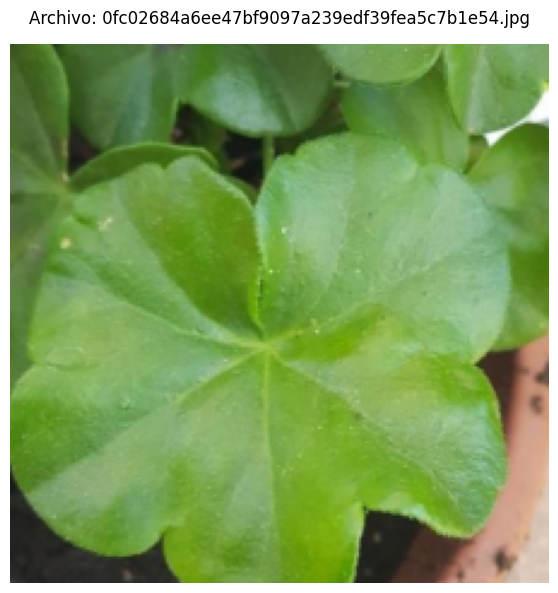

---------------------------------------------------------------------------
TOP 5 PREDICCIONES DEL MODELO (Familia | Género | Especie):
---------------------------------------------------------------------------
1. [Fam: 47] Pelargonium zonale: 45.95%
2. [Fam: 47] Pelargonium inquinans: 20.73%
3. [Fam: 47] Pelargonium zonale: 16.47%
4. [Fam: 47] Pelargonium x hortorum: 4.94%
5. [Fam: 47] Pelargonium x hortorum: 4.53%
---------------------------------------------------------------------------


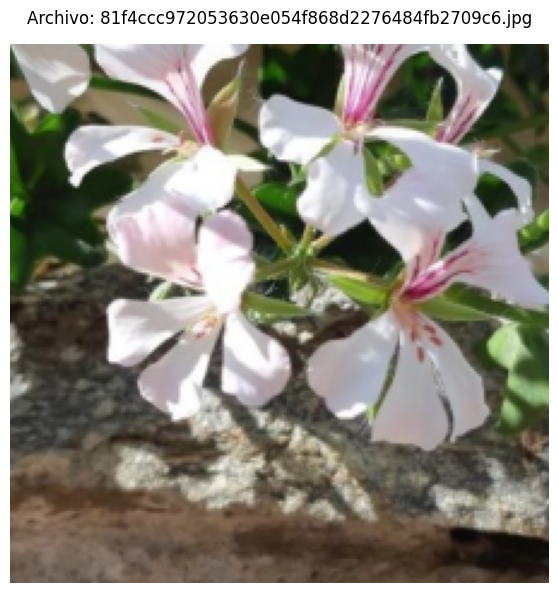

---------------------------------------------------------------------------
TOP 5 PREDICCIONES DEL MODELO (Familia | Género | Especie):
---------------------------------------------------------------------------
1. [Fam: 47] Pelargonium peltatum: 37.44%
2. [Fam: 47] Pelargonium inquinans: 14.82%
3. [Fam: 47] Pelargonium peltatum: 14.73%
4. [Fam: 47] Pelargonium graveolens: 12.56%
5. [Fam: 37] Lycoris squamigera: 3.93%
---------------------------------------------------------------------------


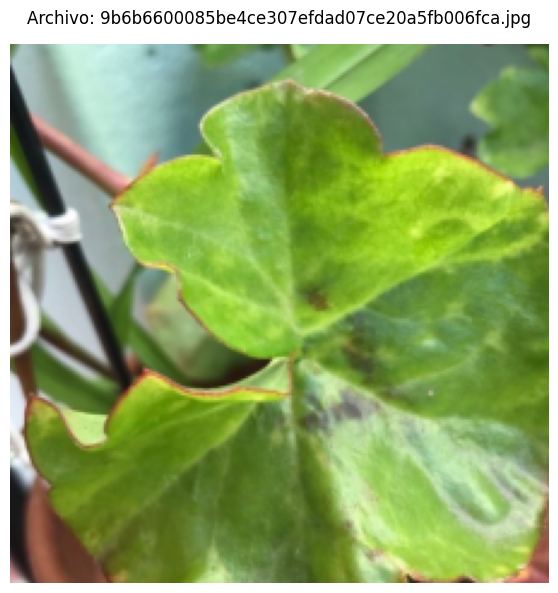

---------------------------------------------------------------------------
TOP 5 PREDICCIONES DEL MODELO (Familia | Género | Especie):
---------------------------------------------------------------------------
1. [Fam: 47] Pelargonium inquinans: 41.73%
2. [Fam: 47] Pelargonium zonale: 35.22%
3. [Fam: 47] Pelargonium zonale: 5.70%
4. [Fam: 47] Pelargonium peltatum: 3.78%
5. [Fam: 47] Pelargonium x hortorum: 3.28%
---------------------------------------------------------------------------


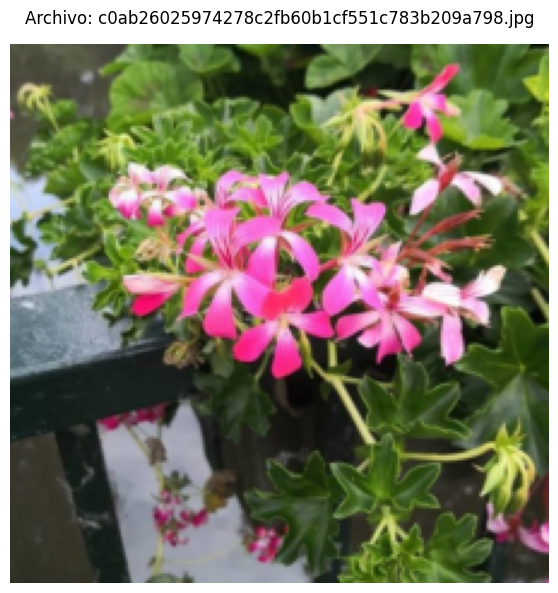

---------------------------------------------------------------------------
TOP 5 PREDICCIONES DEL MODELO (Familia | Género | Especie):
---------------------------------------------------------------------------
1. [Fam: 47] Pelargonium inquinans: 39.61%
2. [Fam: 47] Pelargonium peltatum: 26.74%
3. [Fam: 47] Pelargonium graveolens: 14.91%
4. [Fam: 47] Pelargonium zonale: 11.01%
5. [Fam: 47] Pelargonium peltatum: 4.94%
---------------------------------------------------------------------------


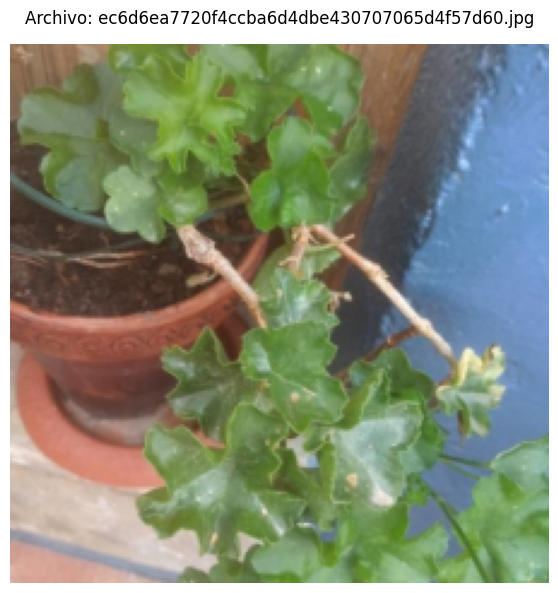

---------------------------------------------------------------------------
TOP 5 PREDICCIONES DEL MODELO (Familia | Género | Especie):
---------------------------------------------------------------------------
1. [Fam: 32] Lactuca sativa: 30.61%
2. [Fam: 47] Pelargonium peltatum: 19.16%
3. [Fam: 47] Pelargonium inquinans: 13.95%
4. [Fam: 47] Pelargonium zonale: 9.00%
5. [Fam: 16] Cymbalaria muralis: 4.64%
---------------------------------------------------------------------------


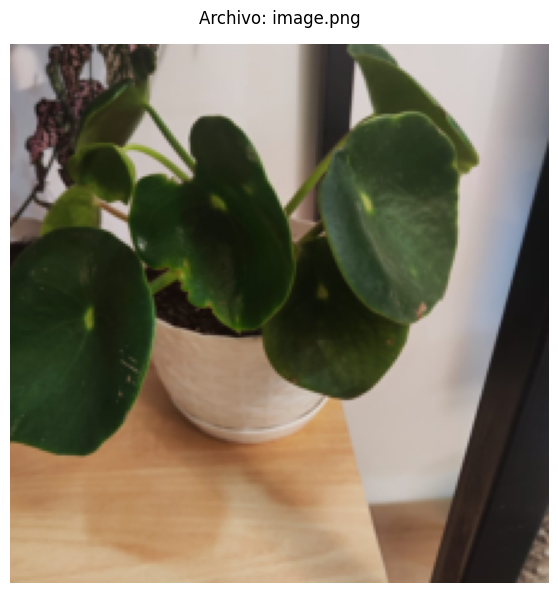

---------------------------------------------------------------------------
TOP 5 PREDICCIONES DEL MODELO (Familia | Género | Especie):
---------------------------------------------------------------------------
1. [Fam: 47] Peperomia polybotrya: 78.31%
2. [Fam: 47] Peperomia obtusifolia: 12.97%
3. [Fam: 47] Peperomia magnoliifolia: 1.71%
4. [Fam: 47] Peperomia serpens: 1.64%
5. [Fam: 47] Peperomia obtusifolia: 1.10%
---------------------------------------------------------------------------


In [12]:
# 5. Iterar y predecir sobre las imágenes
for img_path in image_paths:
    predict_image(img_path)
